# Apriori Algorithm — Association Rule Mining

## What Is Apriori?

Apriori is an **association rule mining** algorithm that discovers meaningful patterns in transactional datasets — specifically, which items tend to appear together. It produces rules of the form:

$$\{A, B\} \Rightarrow \{C\}$$

For example: customers who buy milk and bread also tend to buy butter. The algorithm extracts these co-occurrence patterns automatically from raw transaction data, turning it into interpretable probabilistic rules.

## Core Concepts

**Item** — a single entity in a transaction (e.g. `milk`, `bread`).

**Itemset** — a collection of one or more items: $\{milk, bread\}$.

**Frequent Itemset** — an itemset that appears in at least a minimum fraction of all transactions.

**Association Rule** — an implication of the form $X \Rightarrow Y$, where $X$ and $Y$ are disjoint itemsets ($X \cap Y = \emptyset$). $X$ is called the **antecedent** and $Y$ is the **consequent**.

## The Three Key Metrics

### Support

Support measures how often an itemset appears across all transactions. For an itemset $X$ in a dataset $D$:

$$\text{supp}(X) = \frac{|\{t \in D : X \subseteq t\}|}{|D|}$$

It is simply the fraction of transactions containing $X$. Support tells you how **common** the itemset is.

**Example:** If 3 out of 5 transactions contain milk:

$$\text{supp}(\{milk\}) = \frac{3}{5} = 0.6$$

### Confidence

Confidence measures the **conditional probability** that the consequent appears given the antecedent:

$$\text{conf}(X \Rightarrow Y) = P(Y \mid X) = \frac{\text{supp}(X \cup Y)}{\text{supp}(X)}$$

A confidence of 0.8 for $\{milk\} \Rightarrow \{bread\}$ means: among all transactions containing milk, 80% also contain bread.

**Example:**

$$\text{supp}(\{milk, bread\}) = 0.4, \quad \text{supp}(\{milk\}) = 0.5$$

$$\text{conf}(\{milk\} \Rightarrow \{bread\}) = \frac{0.4}{0.5} = 0.8$$

### Lift

Confidence alone is misleading — if bread is bought in 80% of all transactions anyway, then a confidence of 0.8 for the milk $\Rightarrow$ bread rule is not impressive. Lift corrects for this by normalizing against the baseline frequency of the consequent:

$$\text{lift}(X \Rightarrow Y) = \frac{\text{supp}(X \cup Y)}{\text{supp}(X) \cdot \text{supp}(Y)} = \frac{\text{conf}(X \Rightarrow Y)}{\text{supp}(Y)}$$

| Lift Value | Interpretation |
|---|---|
| $> 1$ | Positive association — items appear together more than by chance |
| $= 1$ | Independence — no association |
| $< 1$ | Negative association — items appear together less than by chance |

A lift of 1.8 means the two items co-occur 1.8 times more often than would be expected if they were independent. **Lift is the most important metric for evaluating rule quality** — a rule with high confidence but lift near 1 is not useful.

## The Apriori Principle

The algorithm is built on one elegant property:

> **If an itemset is frequent, then all of its subsets must also be frequent.**

Equivalently, its **contrapositive**:

> **If any subset of an itemset is infrequent, the entire itemset must be infrequent.**

This is called the **anti-monotonicity property** of support, and it is what makes Apriori computationally tractable.

**Example:** If $\{milk, bread\}$ is infrequent, then $\{milk, bread, butter\}$ cannot possibly be frequent — it appears in a subset of the transactions that contain $\{milk, bread\}$. So we prune $\{milk, bread, butter\}$ immediately, without ever counting it.

Without this pruning, we would need to examine every possible itemset. For $n$ items, there are $2^n$ possible itemsets:

$$n = 100 \implies 2^{100} \approx 10^{30} \text{ itemsets}$$

This is completely intractable. The Apriori principle prunes the search space by orders of magnitude.

## The Algorithm

Apriori proceeds in iterative **passes** over the data, each generating larger candidate itemsets from the frequent itemsets found in the previous pass.

**Step 1 — Frequent 1-itemsets $L_1$:**
Scan the dataset and count the support of every individual item. Keep only those with $\text{supp}(X) \geq \text{min\_support}$. This gives the set of frequent 1-itemsets $L_1$.

**Step 2 — Candidate generation $C_k$ from $L_{k-1}$:**
Generate candidate $k$-itemsets by joining pairs of frequent $(k-1)$-itemsets that share the same first $k-2$ items. This is the **join step**.

**Step 3 — Pruning:**
For each candidate in $C_k$, check all of its $(k-1)$-subsets. If any subset is not in $L_{k-1}$, discard the candidate immediately (Apriori principle). This is the **prune step**.

**Step 4 — Count support:**
Scan the database to count the support of surviving candidates in $C_k$. Keep those meeting the minimum support threshold to form $L_k$.

**Step 5 — Repeat** Steps 2–4 with $k \leftarrow k+1$ until no new frequent itemsets are found.

**Step 6 — Generate rules:**
For every frequent itemset $L$ with $|L| \geq 2$, generate all non-trivial rules $X \Rightarrow Y$ where $X \cup Y = L$ and $X \cap Y = \emptyset$. Keep only rules meeting the minimum confidence (and optionally minimum lift) thresholds.

## Worked Example

Consider the following 6 transactions:

| Transaction | Items |
|---|---|
| T1 | Milk, Bread, Butter |
| T2 | Beer, Diaper, Milk, Bread |
| T3 | Milk, Bread, Diaper, Beer |
| T4 | Bread, Butter |
| T5 | Milk, Diaper, Beer |
| T6 | Bread, Milk, Butter |

With $\text{min\_support} = 0.5$ (at least 3 of 6 transactions):

**Frequent 1-itemsets $L_1$:**

$$\text{supp}(\{Milk\}) = \frac{5}{6} \approx 0.83, \quad \text{supp}(\{Bread\}) = \frac{5}{6} \approx 0.83, \quad \text{supp}(\{Beer\}) = \frac{3}{6} = 0.5$$

$$\text{supp}(\{Butter\}) = \frac{3}{6} = 0.5, \quad \text{supp}(\{Diaper\}) = \frac{3}{6} = 0.5$$

All five items are frequent.

**Frequent 2-itemsets $L_2$** (after counting):

$$\text{supp}(\{Milk, Bread\}) = \frac{4}{6} \approx 0.67$$

**Example rule from this:**

$$\{Milk\} \Rightarrow \{Bread\}: \quad \text{conf} = \frac{0.67}{0.83} \approx 0.80$$

$$\text{lift} = \frac{0.67}{0.83 \times 0.83} \approx 0.97$$

The low lift suggests milk and bread are nearly independent in this small dataset — they are each so common that their co-occurrence is expected.

## Hyperparameters

| Parameter | Meaning | Effect of Increasing |
|---|---|---|
| `min_support` | Minimum fraction of transactions an itemset must appear in | Fewer, more common itemsets found |
| `min_confidence` | Minimum conditional probability for a rule | Fewer, stronger rules |
| `min_lift` | Minimum lift threshold for a rule | Only genuinely associated rules kept |

Choosing these thresholds requires domain knowledge. Setting `min_support` too low produces an explosion of trivial itemsets; too high misses meaningful but rare patterns.

## Limitations

**Computational expense:** Apriori requires **multiple full scans** of the dataset — one scan per itemset size level. For large datasets with many items, this becomes very slow.

**Candidate explosion:** Even with pruning, the number of candidate itemsets can be enormous if many items are frequently co-occurring.

**Binary representation only:** The algorithm treats items as present or absent. It does not handle quantities, timestamps, or continuous values natively.

Two more efficient algorithms address these limitations:

| Algorithm | Key Innovation |
|---|---|
| **FP-Growth** | Compresses transactions into an FP-tree structure; eliminates repeated database scans and candidate generation entirely |
| **Eclat** | Uses a vertical data format (transaction ID lists per itemset); computes support via set intersection rather than scanning |

FP-Growth is typically 10–100$\times$ faster than Apriori on large datasets and is the preferred algorithm in practice.

## Summary

Apriori turns raw transactional data into interpretable probabilistic rules. The three metrics — support, confidence, and lift — together answer three questions about any rule $X \Rightarrow Y$:

- **Support:** Is this pattern common enough to be worth caring about?
- **Confidence:** Given $X$, how reliably does $Y$ follow?
- **Lift:** Is the association genuinely meaningful, or just a coincidence of high base rates?

The Apriori principle makes the search tractable by exploiting the anti-monotonicity of support to prune the exponentially large search space. It is the foundational algorithm for association rule mining, and its key ideas underpin all modern variants.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

dataset = [
    ['Milk','Bread','Butter'],
    ['Beer','Diaper','Milk','Bread'],
    ['Milk','Bread','Diaper','Beer'],
    ['Bread','Butter'],
    ['Milk','Diaper','Beer'],
    ['Bread','Milk','Butter'],
]

In [2]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

te_array = te.fit(dataset).transform(dataset)

df = pd.DataFrame(te_array, columns=te.columns_)

In [3]:
frequent_items = apriori(
    df,
    min_support=0.3,
    use_colnames=True
)

print(frequent_items)

     support                                itemsets
0   0.500000                       frozenset({Beer})
1   0.833333                      frozenset({Bread})
2   0.500000                     frozenset({Butter})
3   0.500000                     frozenset({Diaper})
4   0.833333                       frozenset({Milk})
5   0.333333                frozenset({Beer, Bread})
6   0.500000               frozenset({Beer, Diaper})
7   0.500000                 frozenset({Beer, Milk})
8   0.500000              frozenset({Butter, Bread})
9   0.333333              frozenset({Bread, Diaper})
10  0.666667                frozenset({Milk, Bread})
11  0.333333               frozenset({Butter, Milk})
12  0.500000               frozenset({Milk, Diaper})
13  0.333333        frozenset({Beer, Bread, Diaper})
14  0.333333          frozenset({Beer, Milk, Bread})
15  0.500000         frozenset({Beer, Milk, Diaper})
16  0.333333        frozenset({Butter, Milk, Bread})
17  0.333333        frozenset({Milk, Bread, Di

In [4]:
rules = association_rules(
    frequent_items,
    metric="confidence",
    min_threshold=0.6
)

print(rules[['antecedents','consequents','support','confidence','lift']])

                         antecedents                       consequents  \
0                  frozenset({Beer})                frozenset({Bread})   
1                  frozenset({Beer})               frozenset({Diaper})   
2                frozenset({Diaper})                 frozenset({Beer})   
3                  frozenset({Beer})                 frozenset({Milk})   
4                  frozenset({Milk})                 frozenset({Beer})   
5                frozenset({Butter})                frozenset({Bread})   
6                 frozenset({Bread})               frozenset({Butter})   
7                frozenset({Diaper})                frozenset({Bread})   
8                  frozenset({Milk})                frozenset({Bread})   
9                 frozenset({Bread})                 frozenset({Milk})   
10               frozenset({Butter})                 frozenset({Milk})   
11                 frozenset({Milk})               frozenset({Diaper})   
12               frozenset({Diaper})  

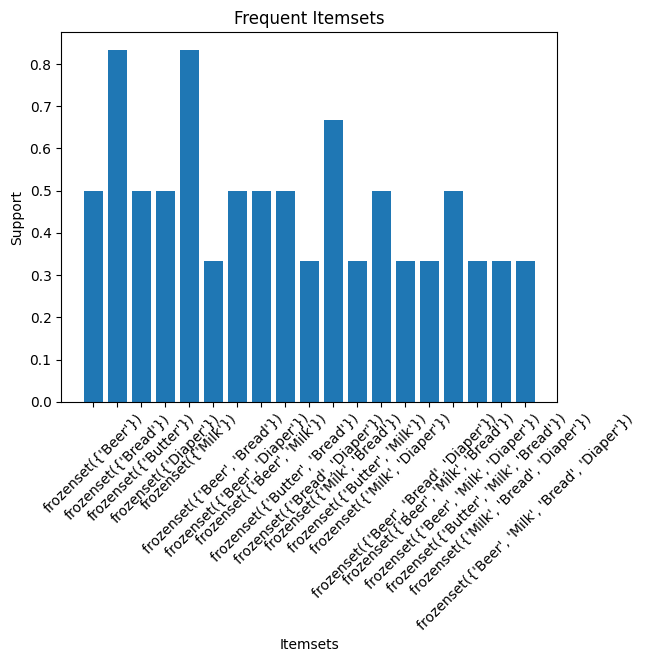

In [5]:
plt.bar(
    frequent_items['itemsets'].astype(str),
    frequent_items['support']
)

plt.xticks(rotation=45)

plt.xlabel("Itemsets")
plt.ylabel("Support")

plt.title("Frequent Itemsets")

plt.show()

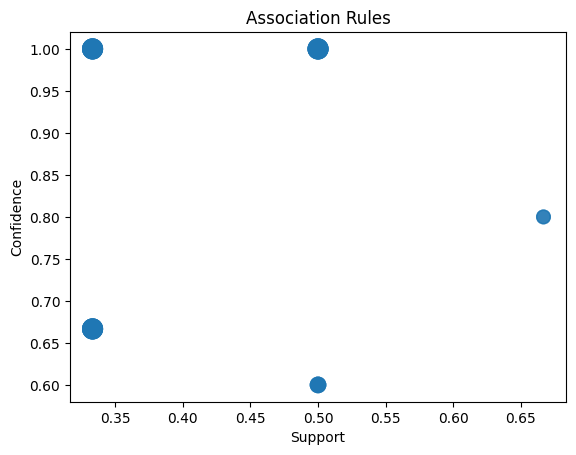

In [6]:
plt.scatter(
    rules['support'],
    rules['confidence'],
    s = rules['lift']*100,
    alpha = 0.7
)

plt.xlabel("Support")
plt.ylabel("Confidence")

plt.title("Association Rules")

plt.show()